In [229]:
import pandas as pd
import seaborn as sns

In [230]:
imdb_data = pd.read_csv("imdb_top_1000.csv")
imdb_data

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN


In [231]:
#Data understanding

In [232]:
movies_data

,Series_Title,Genre,IMDB_Rating
0,The Shawshank Redemption,Drama,9.3
1,The Godfather,"Crime, Drama",9.2
2,The Dark Knight,"Action, Crime, Drama",9.0
3,The Godfather: Part II,"Crime, Drama",9.0
4,12 Angry Men,"Crime, Drama",9.0
...,...,...,...
995,Breakfast at Tiffany's,"Comedy, Drama, Romance",7.6
996,Giant,"Drama, Western",7.6
997,From Here to Eternity,"Drama, Romance, War",7.6
998,Lifeboat,"Drama, War",7.6


In [233]:
movies_data.shape

(1000, 3)

In [234]:
movies_data = imdb_data[["Series_Title","Genre","IMDB_Rating"]]

In [235]:
movies_data.isna().sum()

Series_Title    0
Genre           0
IMDB_Rating     0
dtype: int64

In [236]:
movies_data.describe(include='all')

,Series_Title,Genre,IMDB_Rating
count,1000,1000,1000.000000
unique,999,202,NaN
top,Drishyam,Drama,NaN
freq,2,85,NaN
mean,NaN,NaN,7.949300
std,NaN,NaN,0.275491
min,NaN,NaN,7.600000
25%,NaN,NaN,7.700000
50%,NaN,NaN,7.900000
75%,NaN,NaN,8.100000


In [237]:
movies_data.dtypes

Series_Title        str
Genre               str
IMDB_Rating     float64
dtype: object

In [238]:
pd.DataFrame(movies_data["Genre"].unique())

,0
0,Drama
1,"Crime, Drama"
2,"Action, Crime, Drama"
3,"Action, Adventure, Drama"
4,"Biography, Drama, History"
...,...
197,"Action, Adventure, Family"
198,"Action, Crime, Mystery"
199,"Animation, Drama, Romance"
200,"Drama, War, Western"


In [239]:
movies_data["Genre"].nunique()

202

### Model Building

In [240]:
piv_table = pd.pivot_table(data = movies_data, values = 'IMDB_Rating', index = "Genre", columns= 'Series_Title').fillna(0)
piv_table

Series_Title,(500) Days of Summer,12 Angry Men,12 Years a Slave,1917,2001: A Space Odyssey,21 Grams,25th Hour,28 Days Later...,3 Idiots,300,...,Zelig,Zerkalo,Zindagi Na Milegi Dobara,Zodiac,Zombieland,Zootopia,Zulu,Zwartboek,À bout de souffle,Ôkami kodomo no Ame to Yuki
Genre,,,,,,,,,,,,,,,,,,,,,
"Action, Adventure",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Action, Adventure, Biography",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Action, Adventure, Comedy",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Action, Adventure, Crime",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Action, Adventure, Drama",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Mystery, Romance, Thriller",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Mystery, Sci-Fi, Thriller",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Mystery, Thriller",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [241]:
piv_table.corr().round(3)

Series_Title,(500) Days of Summer,12 Angry Men,12 Years a Slave,1917,2001: A Space Odyssey,21 Grams,25th Hour,28 Days Later...,3 Idiots,300,...,Zelig,Zerkalo,Zindagi Na Milegi Dobara,Zodiac,Zombieland,Zootopia,Zulu,Zwartboek,À bout de souffle,Ôkami kodomo no Ame to Yuki
Series_Title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer,1.000,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,...,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005
12 Angry Men,-0.005,1.000,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,...,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,1.000,-0.005
12 Years a Slave,-0.005,-0.005,1.000,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,...,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005
1917,-0.005,-0.005,-0.005,1.000,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,...,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,1.000,-0.005,-0.005
2001: A Space Odyssey,-0.005,-0.005,-0.005,-0.005,1.000,-0.005,-0.005,-0.005,-0.005,-0.005,...,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zootopia,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,...,-0.005,-0.005,-0.005,-0.005,-0.005,1.000,-0.005,-0.005,-0.005,-0.005
Zulu,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,...,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,1.000,-0.005,-0.005,-0.005
Zwartboek,-0.005,-0.005,-0.005,1.000,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,...,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,1.000,-0.005,-0.005


In [242]:
from sklearn.metrics import pairwise_distances

In [243]:
pairwise_data = pd.DataFrame(
    pairwise_distances(X=piv_table, metric="euclidean"),
    index=piv_table.index,
    columns=piv_table.index
)
pairwise_data

Genre,"Action, Adventure","Action, Adventure, Biography","Action, Adventure, Comedy","Action, Adventure, Crime","Action, Adventure, Drama","Action, Adventure, Family","Action, Adventure, Fantasy","Action, Adventure, History","Action, Adventure, Horror","Action, Adventure, Mystery",...,Horror,"Horror, Mystery, Sci-Fi","Horror, Mystery, Thriller","Horror, Sci-Fi","Horror, Thriller","Mystery, Romance, Thriller","Mystery, Sci-Fi, Thriller","Mystery, Thriller",Thriller,Western
Genre,,,,,,,,,,,,,,,,,,,,,
"Action, Adventure",0.000000,19.932386,30.998387,19.815398,35.605337,19.815398,27.186578,19.932386,19.932386,19.815398,...,21.441315,20.012496,24.123640,21.557829,21.367967,20.094278,21.369371,30.141500,19.892964,24.785278
"Action, Adventure, Biography",19.932386,0.000000,26.237759,10.962208,31.547742,10.962208,21.601620,11.172287,11.172287,10.962208,...,13.683932,11.314592,17.591759,13.865785,13.568714,11.458621,13.570925,25.219635,11.101802,18.488645
"Action, Adventure, Comedy",30.998387,26.237759,0.000000,26.148996,39.482401,26.148996,32.097196,26.237759,26.237759,26.148996,...,27.401642,26.298669,29.547758,27.492908,27.344286,26.360956,27.345384,34.635675,26.207823,30.090364
"Action, Adventure, Crime",19.815398,10.962208,26.148996,0.000000,31.473957,10.748023,21.493720,10.962208,10.962208,10.748023,...,13.512957,11.107205,17.459095,13.697080,13.396268,11.253888,13.398507,25.127276,10.890363,18.362462
"Action, Adventure, Drama",35.605337,31.547742,39.482401,31.473957,0.000000,31.473957,36.565968,31.547742,31.547742,31.473957,...,32.522146,31.598418,34.349818,32.599080,32.473836,31.650276,32.474759,38.813271,31.522849,34.817668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Mystery, Romance, Thriller",20.094278,11.458621,26.360956,11.253888,31.650276,11.253888,21.751092,11.458621,11.458621,11.253888,...,13.918692,11.597414,17.774982,14.097518,13.805434,0.000000,13.807607,25.347781,11.389908,18.663065
"Mystery, Sci-Fi, Thriller",21.369371,13.570925,27.345384,13.398507,32.474759,13.398507,22.934254,13.570925,13.570925,13.398507,...,15.703503,13.688316,19.204687,15.862219,15.603205,13.807607,0.000000,26.370059,13.512957,20.029478
"Mystery, Thriller",30.141500,25.219635,34.635675,25.127276,38.813271,25.127276,31.270433,25.219635,25.219635,25.127276,...,26.428394,25.282998,28.647513,26.523009,26.368921,25.347781,26.370059,0.000000,25.188489,29.206849


<Axes: xlabel='Genre', ylabel='Genre'>

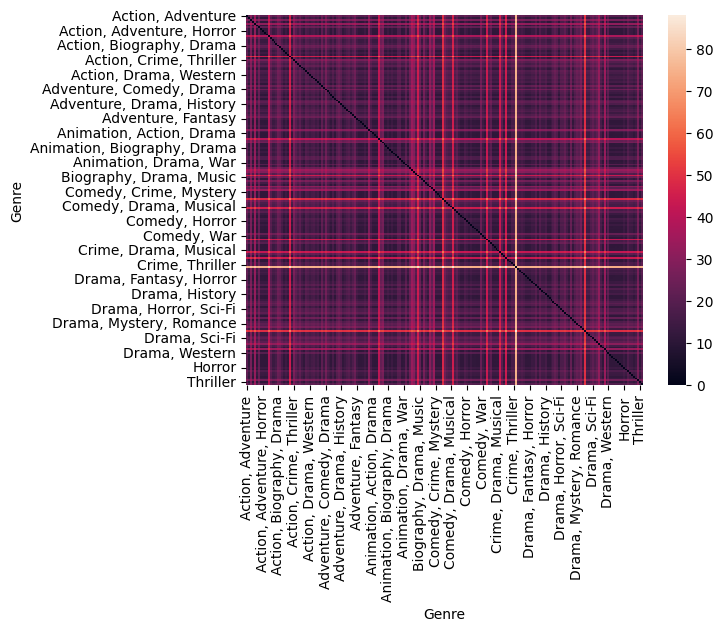

In [244]:
sns.heatmap(pairwise_data)

In [245]:
corr_data = pairwise_data.iloc[:20,:20]

<Axes: xlabel='Genre', ylabel='Genre'>

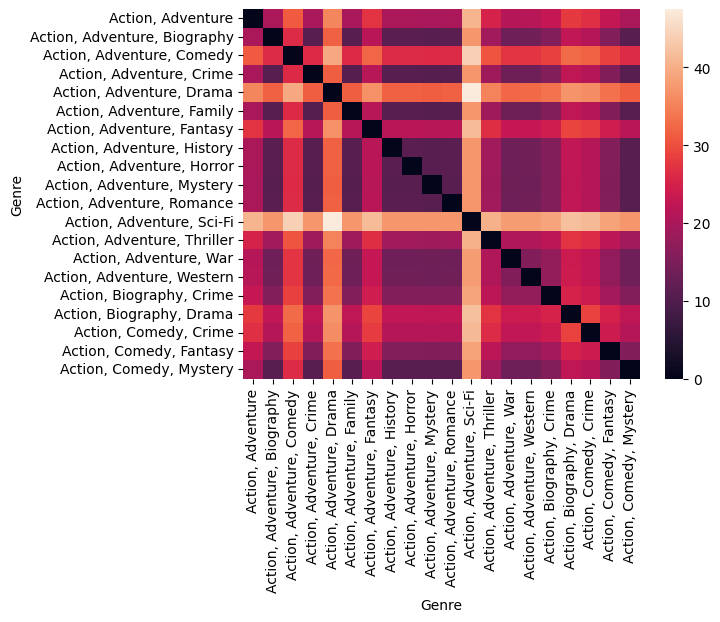

In [246]:
sns.heatmap(corr_data)

In [247]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize the vectorizer
vectorizer = CountVectorizer()

# 2. Provide your text data
corpus = [
    'The quick brown fox',
    'Brown fox jumps over the lazy dog'
]

# 3. Learn the vocabulary and create the matrix
X = vectorizer.fit_transform(corpus)

# 4. View the extracted vocabulary
print(vectorizer.get_feature_names_out())

# 5. View the numerical array
print(X.toarray())


['brown' 'dog' 'fox' 'jumps' 'lazy' 'over' 'quick' 'the']
[[1 0 1 0 0 0 1 1]
 [1 1 1 1 1 1 0 1]]


# ==================================================================

In [248]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [249]:
ratings = pd.read_csv('u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
ratings

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [250]:
movies = pd.read_csv('u.item', sep='|',encoding='latin-1',header=None)
movies = movies[[0, 1]]
movies.columns = ['item_id', 'title']
df = pd.merge(ratings, movies, on='item_id')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
df

,user_id,item_id,rating,timestamp,title
0,196,242,3,1997-12-04 15:55:49,Kolya (1996)
1,186,302,3,1998-04-04 19:22:22,L.A. Confidential (1997)
2,22,377,1,1997-11-07 07:18:36,Heavyweights (1994)
3,244,51,2,1997-11-27 05:02:03,Legends of the Fall (1994)
4,166,346,1,1998-02-02 05:33:16,Jackie Brown (1997)
...,...,...,...,...,...
99995,880,476,3,1997-11-22 05:10:44,"First Wives Club, The (1996)"
99996,716,204,5,1997-11-17 19:39:03,Back to the Future (1985)
99997,276,1090,1,1997-09-20 22:49:55,Sliver (1993)
99998,13,225,2,1997-12-17 22:52:36,101 Dalmatians (1996)


### popular_recommendations

In [251]:
def popular_recommendations(top_n=5):
    pop = df.groupby('title').agg({'rating': ['mean', 'count']})
    pop.columns = ['avg_rating', 'count']
    pop = pop[pop['count'] > 50]  
    pop = pop.sort_values(by=['avg_rating'], ascending=False) 
    return pop.head(top_n).index.tolist()      

In [252]:
popular_recommendations()

['Close Shave, A (1995)',
 "Schindler's List (1993)",
 'Wrong Trousers, The (1993)',
 'Casablanca (1942)',
 'Wallace & Gromit: The Best of Aardman Animation (1996)']

### trending_recommendations

In [253]:
def trending_recommendations(top_n=5):
    recent = df[df['timestamp'] > '1998-01-01']
    trend = recent.groupby('title').agg({'rating': ['mean', 'count']})
    trend.columns = ['avg_rating', 'count']
    trend = trend.sort_values(by=['count'], ascending=False)
    return trend.head(top_n)#.index.tolist()


In [254]:
trending_recommendations()

,avg_rating,count
title,,
Titanic (1997),4.242236,322
Contact (1997),3.704545,264
Star Wars (1977),4.379032,248
Air Force One (1997),3.572614,241
Scream (1996),3.420168,238


In [255]:
cv = CountVectorizer(stop_words='english')

In [256]:
matrix = cv.fit_transform(movies['title'])
content_similarity = cosine_similarity(matrix)
pd.DataFrame(content_similarity).round(2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.00,0.41,0.41,0.41,0.41,0.15,0.41,0.41,0.29,0.33,...,0.41,0.0,0.0,0.0,0.41,0.0,0.00,0.00,0.0,0.0
1,0.41,1.00,0.50,0.50,0.50,0.18,0.50,0.50,0.35,0.41,...,0.50,0.0,0.0,0.0,0.50,0.0,0.00,0.00,0.0,0.0
2,0.41,0.50,1.00,0.50,0.50,0.18,0.50,0.50,0.35,0.41,...,0.50,0.0,0.0,0.0,0.50,0.0,0.00,0.00,0.0,0.0
3,0.41,0.50,0.50,1.00,0.50,0.18,0.50,0.50,0.35,0.41,...,0.50,0.0,0.0,0.0,0.50,0.0,0.00,0.00,0.0,0.0
4,0.41,0.50,0.50,0.50,1.00,0.18,0.50,0.50,0.35,0.41,...,0.50,0.0,0.0,0.0,0.50,0.0,0.00,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.0,0.0,0.00,1.0,0.00,0.00,0.0,0.0
1678,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.0,0.0,0.00,0.0,1.00,0.41,0.0,0.0
1679,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.0,0.0,0.00,0.0,0.41,1.00,0.0,0.0
1680,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.00,1.0,0.0


In [257]:
matrix = cv.fit_transform(movies['title'])
content_similarity = pairwise_distances(matrix)
pd.DataFrame(content_similarity).round(2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,0.00,1.73,1.73,1.73,1.73,4.00,1.73,1.73,2.24,2.00,...,1.73,2.45,2.24,2.45,1.73,2.45,2.24,2.45,2.24,3.00
1,1.73,0.00,1.41,1.41,1.41,3.87,1.41,1.41,2.00,1.73,...,1.41,2.24,2.00,2.24,1.41,2.24,2.00,2.24,2.00,2.83
2,1.73,1.41,0.00,1.41,1.41,3.87,1.41,1.41,2.00,1.73,...,1.41,2.24,2.00,2.24,1.41,2.24,2.00,2.24,2.00,2.83
3,1.73,1.41,1.41,0.00,1.41,3.87,1.41,1.41,2.00,1.73,...,1.41,2.24,2.00,2.24,1.41,2.24,2.00,2.24,2.00,2.83
4,1.73,1.41,1.41,1.41,0.00,3.87,1.41,1.41,2.00,1.73,...,1.41,2.24,2.00,2.24,1.41,2.24,2.00,2.24,2.00,2.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,2.45,2.24,2.24,2.24,2.24,4.24,2.24,2.24,2.65,2.45,...,2.24,2.45,2.24,2.45,2.24,0.00,2.24,2.45,2.24,3.00
1678,2.24,2.00,2.00,2.00,2.00,4.12,2.00,2.00,2.45,2.24,...,2.00,2.24,2.00,2.24,2.00,2.24,0.00,1.73,2.00,2.83
1679,2.45,2.24,2.24,2.24,2.24,4.24,2.24,2.24,2.65,2.45,...,2.24,2.45,2.24,2.45,2.24,2.45,1.73,0.00,2.24,3.00
1680,2.24,2.00,2.00,2.00,2.00,4.12,2.00,2.00,2.45,2.24,...,2.00,2.24,2.00,2.24,2.00,2.24,2.00,2.24,0.00,2.83


### content recomendations

In [258]:
def content_recommendations(movie_name, top_n=5):
    if movie_name not in movies['title'].values:
        return ["Movie not found"]
    
    idx = movies[movies['title'] == movie_name].index[0]
    scores = list(enumerate(content_similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    return [movies.iloc[i[0]].title for i in scores]

In [259]:
content_recommendations('Zootopia')

['Movie not found']

In [260]:
div = lambda x : x[1]
div(87)

TypeError: 'int' object is not subscriptable

In [ ]:
enumerate(content_similarity)

In [ ]:
import numpy as np

<Axes: >

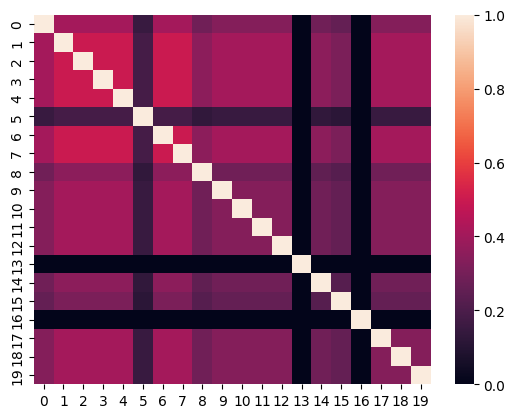

In [ ]:
sns.heatmap(content_similarity[:20,:20])